In [14]:
import cmdstanpy
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

## Simulating data
We are simulating 15 presence counts assuming 12.5 average attendance.

In [15]:
exercise01_df = pd.DataFrame({'PresentN': np.random.poisson(12.5, 15)})

## Model

Create a model in Stan for count data. The distribution you sample data from is [poisson(lambda)](https://mc-stan.org/docs/functions-reference/unbounded_discrete_distributions.html#poisson). The parameter $\lambda$ can be sampled from prior distribution $lognormal(2.5, 0.35)$.

$$PresentN \sim Poisson(\lambda)$$
$$\lambda \sim LogNormal(2.5, 0.35)$$

## Compiling the model

In [16]:
exercise01_model = cmdstanpy.CmdStanModel(stan_file="Stan/exercise01.stan")

## Preparing the data in Stan format

In [17]:
exercise01_standata = {
  'N' : len(exercise01_df),
  'PresentN' : exercise01_df.PresentN
}

## Sampling the model

In [18]:
exercise01_fit = exercise01_model.sample(
    data=exercise01_standata,
    chains=4,
    parallel_chains=os.cpu_count())

22:25:21 - cmdstanpy - INFO - Requested 8 parallel_chains but only 4 required, will run all chains in parallel.
22:25:21 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

22:25:21 - cmdstanpy - INFO - CmdStan done processing.


## Extracting samples

In [19]:
exercise01_samples = exercise01_fit.draws_pd()

## Plot posterior distribution for attendance

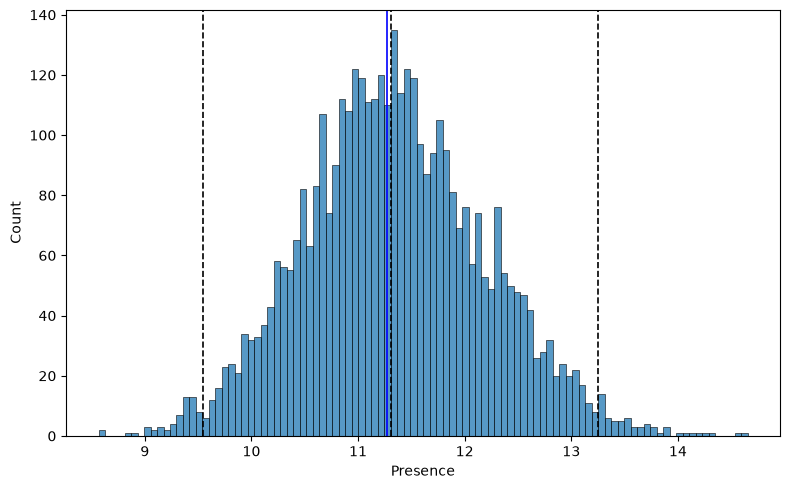

In [20]:
# compute 97% credible interval + median
lambda_quantiles = np.quantile(exercise01_samples["lambda"], [(1 - 0.97) / 2, 0.5, 1 - (1 - 0.97) / 2])

# plot posterior distribution for probability of correct response
plt.figure(figsize=(8, 5))
sns.histplot(exercise01_samples["lambda"], bins=100, stat="count")
for x in lambda_quantiles:
    plt.axvline(x, color="black", linestyle="--", linewidth=1.2)
plt.axvline(exercise01_df.PresentN.mean(), color="blue", linestyle="-", linewidth=1.2)

plt.xlabel("Presence")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Compute probablity that performance is above 12

In [21]:
np.mean(exercise01_samples['lambda']>12)

np.float64(0.21525)